# Explore the MatrAIx wiki profiles

Quick, **read-only** exploration of the wiki person profiles DB
(`data/wiki/matraix_wiki_profiles_20260601_v1.sqlite`, ~2.13M rows): profile
**length** (chars + Qwen tokens) and available **metadata** (source language,
shards, Wikidata QID, name script/origin diversity).

> No GPU / vLLM needed — only sqlite + the Qwen tokenizer (for token counts).
> Kernel: env05 (`/n/home08/xiaominli/.conda/envs/env05`).

## 0. Config & connect

In [1]:
import os
import re
import sqlite3
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CACHE = "/n/netscratch/lu_lab/Lab/xiaominli/mycache/hf_home"
os.environ.setdefault("HF_HOME", CACHE)
os.environ.setdefault("HF_HUB_CACHE", f"{CACHE}/hub")
os.environ.setdefault("HF_XET_CACHE", f"{CACHE}/xet")

REPO = Path("/n/netscratch/lu_lab/Lab/xiaominli/LLMResearch/MatrAIx")
DB = REPO / "persona/human_extraction/data/wiki/matraix_wiki_profiles_20260601_v1.sqlite"
MODEL_ID = "Qwen/Qwen3.6-35B-A3B"

conn = sqlite3.connect(f"file:{DB}?mode=ro", uri=True)
print("DB:", DB, "exists=", DB.exists())

DB: /n/netscratch/lu_lab/Lab/xiaominli/LLMResearch/MatrAIx/persona/human_extraction/data/wiki/matraix_wiki_profiles_20260601_v1.sqlite exists= True


## 1. Table overview

Single `profiles` table. `qid` = Wikidata ID, `source_file` = source shard,
`profile_text` = the article-derived person description.

In [2]:
n_rows = conn.execute("SELECT COUNT(*) FROM profiles").fetchone()[0]
cols = [r[1] for r in conn.execute("PRAGMA table_info(profiles)")]
print(f"total profiles : {n_rows:,}")
print("columns        :", cols)

pd.set_option("display.max_colwidth", 90)
pd.read_sql_query(
    "SELECT global_idx, qid, title, source_url, source_file, "
    "substr(profile_text,1,80) AS profile_head FROM profiles ORDER BY global_idx LIMIT 5",
    conn,
)

total profiles : 2,125,897
columns        : ['global_idx', 'task_id', 'page_id', 'qid', 'title', 'source_url', 'profile_text', 'input_sha256', 'source_file', 'source_row']


,global_idx,qid,title,source_url,source_file,profile_head
0,0,Q41746,Achilles,https://en.wikipedia.org/wiki/Achilles,part-00000.jsonl.gz,"In Greek mythology, Achilles or Achilleus was a hero of the Trojan War who was k"
1,1,Q91,Abraham Lincoln,https://en.wikipedia.org/wiki/Abraham_Lincoln,part-00000.jsonl.gz,"Abraham Lincoln (February 12, 1809 - April 15, 1865) was the 16th president of t"
2,2,Q868,Aristotle,https://en.wikipedia.org/wiki/Aristotle,part-00000.jsonl.gz,Aristotle (; 384–322 BC) was an ancient Greek philosopher and polymath. His writ
3,3,Q132524,Ayn Rand,https://en.wikipedia.org/wiki/Ayn_Rand,part-00000.jsonl.gz,"Alice O'Connor (born Alisa Zinovyevna Rosenbaum;, 1905March 6, 1982), better kno"
4,4,Q313590,Alain Connes,https://en.wikipedia.org/wiki/Alain_Connes,part-00000.jsonl.gz,"Alain Connes (; born 1 April 1947 ) is a French mathematician, known for his con"


## 2. Profile length distribution (chars + Qwen tokens)

Sample N random profiles and measure both character and token length.

In [3]:
from transformers import AutoTokenizer

N_SAMPLE = 20000
rows = conn.execute(
    "SELECT title, profile_text FROM profiles ORDER BY RANDOM() LIMIT ?", (N_SAMPLE,)
).fetchall()
titles = [r[0] or "" for r in rows]
texts = [r[1] or "" for r in rows]

char_lens = np.array([len(t) for t in texts])
word_lens = np.array([len(t.split()) for t in texts])

tok = AutoTokenizer.from_pretrained(MODEL_ID, cache_dir=f"{CACHE}/hub")
tok_lens = np.array([len(x) for x in tok(texts, add_special_tokens=False)["input_ids"]])

def stats(a, name):
    def p(q):
        return int(np.percentile(a, q))
    print(f"{name:8s} mean={a.mean():8.0f}  p50={p(50):>7,}  p90={p(90):>7,}  "
          f"p99={p(99):>7,}  max={a.max():>8,}")

print(f"n sampled: {len(texts):,}")
stats(char_lens, "chars")
stats(word_lens, "words")
stats(tok_lens, "tokens")
print(f"\nchars/token ratio: {char_lens.sum()/tok_lens.sum():.2f}")

/n/home08/xiaominli/.conda/envs/env05/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


n sampled: 20,000
chars    mean=    2876  p50=  1,628  p90=  6,324  p99= 20,529  max= 124,942
words    mean=     469  p50=    267  p90=  1,018  p99=  3,296  max=  20,675
tokens   mean=     723  p50=    422  p90=  1,572  p99=  5,033  max=  27,002

chars/token ratio: 3.98


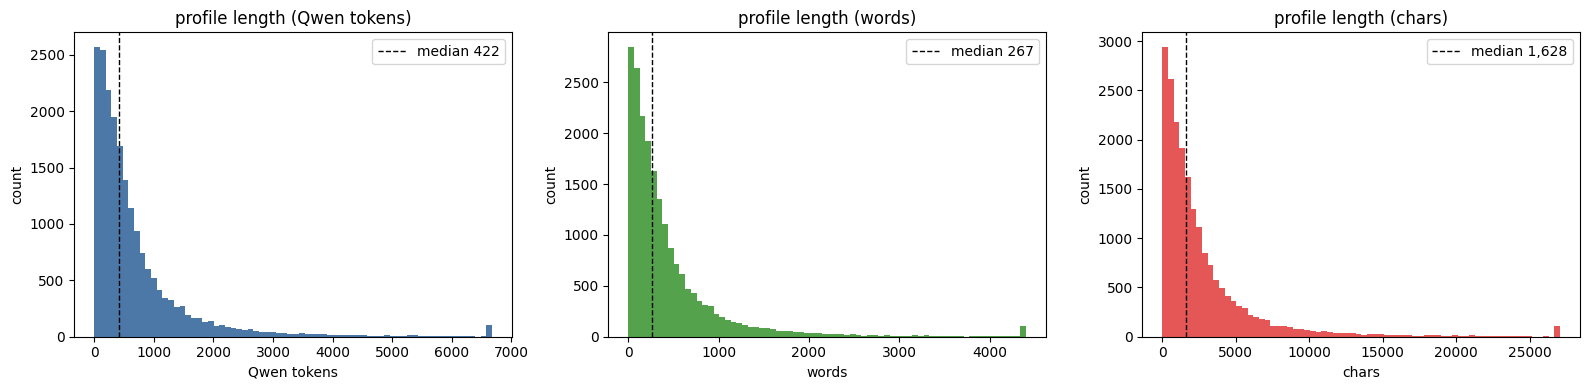

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, (arr, name, col) in zip(ax, [
    (tok_lens, "Qwen tokens", "#4C78A8"),
    (word_lens, "words", "#54A24B"),
    (char_lens, "chars", "#E45756"),
]):
    a.hist(np.clip(arr, 0, np.percentile(arr, 99.5)), bins=70, color=col)
    a.set(title=f"profile length ({name})", xlabel=name, ylabel="count")
    a.axvline(np.median(arr), color="k", ls="--", lw=1, label=f"median {int(np.median(arr)):,}")
    a.legend()
plt.tight_layout()
plt.show()

## 3. Source metadata: language, shards, QID

- **Source language:** derived from the `source_url` host. (These profiles are
  built from **English** Wikipedia, so expect `en.wikipedia.org` throughout —
  there is no per-profile source-language column.)
- **Shards:** `source_file` = which `part-*.jsonl.gz` the row came from.
- **QID:** every row maps to a unique Wikidata entity.

In [5]:
# Source host (language of the source wiki) over a large random sample
hosts = Counter()
for (u,) in conn.execute("SELECT source_url FROM profiles ORDER BY RANDOM() LIMIT 100000"):
    m = re.match(r"https?://([^/]+)/", u or "")
    hosts[m.group(1) if m else "?"] += 1
print("source_url host (100k sample):", hosts.most_common(8))

n_qid = conn.execute("SELECT COUNT(DISTINCT qid) FROM profiles").fetchone()[0]
n_null_qid = conn.execute("SELECT COUNT(*) FROM profiles WHERE qid IS NULL").fetchone()[0]
n_shard = conn.execute("SELECT COUNT(DISTINCT source_file) FROM profiles").fetchone()[0]
print(f"\ndistinct qid : {n_qid:,}  (null: {n_null_qid})  → unique per row")
print(f"shards       : {n_shard}")

# rows per shard
shard_df = pd.read_sql_query(
    "SELECT source_file, COUNT(*) AS n FROM profiles GROUP BY source_file ORDER BY n DESC",
    conn,
)
print(f"rows/shard: mean={shard_df.n.mean():.0f} min={shard_df.n.min():,} max={shard_df.n.max():,}")
shard_df.head()

source_url host (100k sample): [('en.wikipedia.org', 100000)]

distinct qid : 2,125,897  (null: 0)  → unique per row
shards       : 70
rows/shard: mean=30370 min=2,726 max=47,387


,source_file,n
0,part-00002.jsonl.gz,47387
1,part-00069.jsonl.gz,45054
2,part-00001.jsonl.gz,44399
3,part-00037.jsonl.gz,44015
4,part-00029.jsonl.gz,43887


## 4. Name script / origin diversity

The article language is English, but the **people** span many cultures. We can
detect the dominant Unicode script of each `title` (person name) as a rough proxy
for origin — e.g. Latin vs Cyrillic vs CJK vs Arabic. (Note: most non-Western
figures are still titled in Latin transliteration on English Wikipedia, so this
under-counts non-Latin origins.)

In [6]:
import unicodedata

def dominant_script(s: str) -> str:
    counts = Counter()
    for ch in s:
        if ch.isspace() or not ch.isalpha():
            continue
        try:
            name = unicodedata.name(ch)
        except ValueError:
            continue
        script = name.split(" ")[0]  # e.g. LATIN, CYRILLIC, CJK, ARABIC, HANGUL...
        counts[script] += 1
    return counts.most_common(1)[0][0] if counts else "NONE"

scripts = Counter(dominant_script(t) for t in titles)
non_ascii = sum(1 for t in titles if any(ord(c) > 127 for c in t))
print(f"titles with any non-ASCII char: {non_ascii:,} / {len(titles):,} "
      f"({100*non_ascii/len(titles):.1f}%)")
print("\ndominant name script (title):")
for s, n in scripts.most_common(12):
    print(f"  {s:10s} {n:6,}  ({100*n/len(titles):.1f}%)")

titles with any non-ASCII char: 2,003 / 20,000 (10.0%)

dominant name script (title):
  LATIN      20,000  (100.0%)


In [7]:
# A few example titles that are non-Latin script
examples = [t for t in titles if dominant_script(t) not in ("LATIN", "NONE")][:15]
print("non-Latin title examples:")
for t in examples:
    print("  ", t, "->", dominant_script(t))

non-Latin title examples:


## 5. Notes

- **Source language = English** (all `en.wikipedia.org`); there is no multilingual
  source metadata in this DB. Any "language" persona attributes come from the
  *extraction* (the `lang_*` dimensions), not from the source rows.
- Profiles are short: median ~400 Qwen tokens; long tail up to ~25k (see the
  extraction runbook for how truncation/context is handled).
- `qid` is a clean unique key → good for dedup / joining to Wikidata.
- Name-script diversity gives a rough origin signal; combine with the extracted
  `region` / `lang_*` / `demo_ethnicity_*` dimensions for real demographics.